In [112]:

import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import math

# # import  settings
import plot_settings
plot_settings.apply()

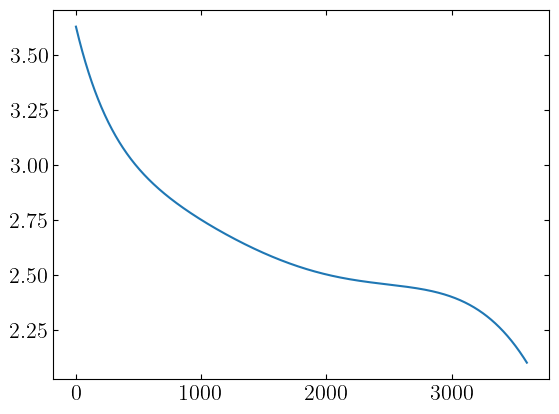

In [176]:
a = [3.8194,-4.6554,-8.901,19.3256,-11.956,3.2912, 3.2518]
R0 = 3.8 - a[-1]

R1 = 0.3

R2 =R1

C1 = 1000
C2 = C1

i0 = 1.0
tf = 3600
Q = 3600
t = np.linspace(0, tf, 1000)

a = a[::-1] 

def dirac_delta(t):
    return np.where(t == 0, 1, 0)

def terms(n,t,a=a, i0=i0, Q=Q):
    n = n
    m = 2 * n -1 
    return a[n] * (i0/Q)**n * t**m / math.factorial(m)


def powers(x, n):
    return np.array([x**k for k in range(n, -1, -1)])

def V_soc(a = a,t = t,i0=i0,Q=Q):
    V = 0
    for i in range(1,len(a)):
        V+= terms(i,t,a,i0,Q)
        
    #V = a[1] * (i0/Q) * t + a[2] * (i0/Q)**2 * t**3 / 6 + a[3] * (i0/Q)**3 * t**5 / 120 + a[4] * (i0/Q)**4 * t**7 / 5040 + a[5] * (i0/Q)**5 * t**9 / 362880 + a[6] * (i0/Q)**6 * t**11 / 39916800

    return a[0] + SOC(i0,t,Q) * a[1] + SOC(i0,t,Q)**2 * a[2] + SOC(i0,t,Q)**3 * a[3] + SOC(i0,t,Q)**4 * a[4] + SOC(i0,t,Q)**5 * a[5] + SOC(i0,t,Q)**6 * a[6]
#np.dot(powers(SOC(i0,t,Q), len(a)-1).T, a)

def simulate(R0, R1, C1,R2,C2, i0 = i0,t = t):
    U = V_soc() - i0*(R0+ R1 * (1 - np.exp(-t / (R1 * C1))) +  R2 * (1 - np.exp(-t / (R2 * C2))))

    return t, U

def SOC(i0, t = t, Q = Q):
    return 1 - i0 * t / Q



plt.plot(*simulate(R0, R1, C1,R2,C2), label = 'R0 = {}, R1 = {}, C = {}'.format(R0, R1, C))
#plt.plot(SOC(i0),V_soc(a), label = 'R0 = {}, R1 = {}, C = {}'.format(R0, R1, C))
#plt.plot(t,SOC(i0, t, Q), label = 'R0 = {}, R1 = {}, C = {}'.format(R0, R1, C))




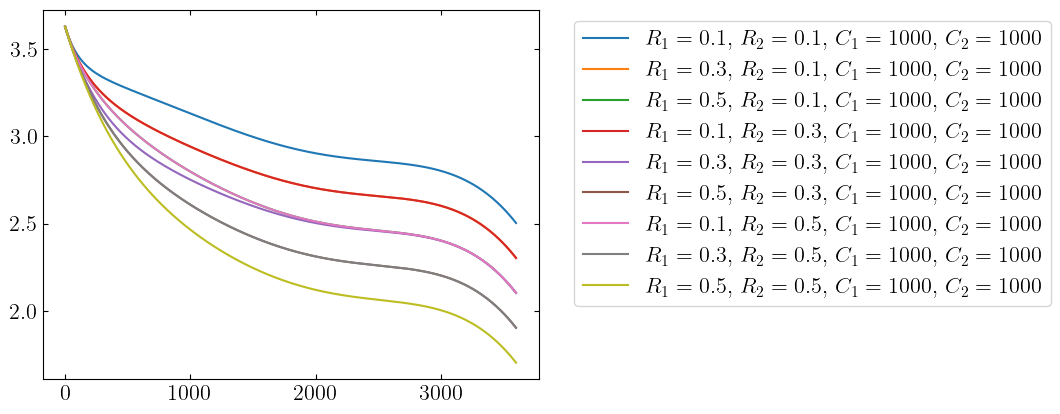

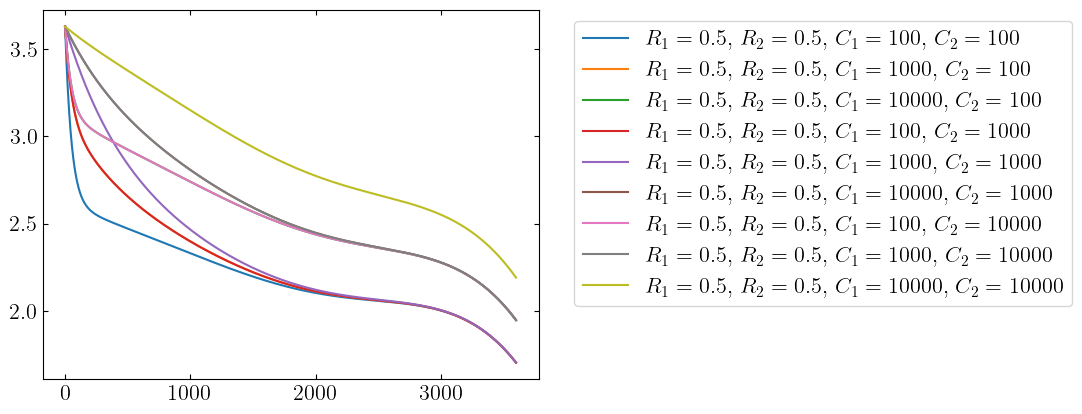

In [188]:
plt.figure()
for R2 in [0.1, 0.3, 0.5]:
    for R1 in [0.1, 0.3, 0.5]:
        plt.plot(*simulate(R0, R1, C1,R2,C2), label = f'$R_1={R1}$, $R_2 = {R2}$, $C_1 = {C1}$, $C_2 = {C2}$')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.figure()
for C2 in [100, 1000, 10000]:
    for C1 in [100, 1000, 10000]:
        plt.plot(*simulate(R0, R1, C1,R2,C2), label = f'$R_1={R1}$, $R_2 = {R2}$, $C_1 = {C1}$, $C_2 = {C2}$')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')